# Sales Data Analysis

## Data Loading

---

In [ ]:
import pandas as pd
orders = pd.read_excel("List_of_Orders.xlsx")
details = pd.read_excel("Order_Details.xlsx")
targets = pd.read_excel("Sales_target.xlsx")

## Dataset Preview

---

### Orders Dataset

In [55]:
display(orders.head())

,Order ID,Order Date,CustomerName,State,City
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune
2,B-25603,2018-03-04 00:00:00,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-03-04 00:00:00,Divsha,Rajasthan,Jaipur
4,B-25605,2018-05-04 00:00:00,Kasheen,West Bengal,Kolkata


### Order Details Dataset

In [57]:
display(details.head())

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275,-1148,7,Furniture,Bookcases
1,B-25601,66,-12,5,Clothing,Stole
2,B-25601,8,-2,3,Clothing,Hankerchief
3,B-25601,80,-56,4,Electronics,Electronic Games
4,B-25602,168,-111,2,Electronics,Phones


### Sales target Dataset

In [56]:
display(targets.head())

,Month of Order Date,Category,Target
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900


## Dataset Overview

---

In [58]:
print("Orders:", orders.shape)
print("Order Details:", details.shape)
print("Sales Targets:", targets.shape)

Orders: (500, 5)
Order Details: (1500, 6)
Sales Targets: (36, 3)


## Data Quality Assessment

### Orders Dataset

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB


### Order Details Dataset

In [9]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
dtypes: int64(3), object(3)
memory usage: 70.4+ KB


### Sales Target Dataset

In [ ]:
targets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Month of Order Date  36 non-null     datetime64[ns]
 1   Category             36 non-null     object        
 2   Target               36 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 996.0+ bytes


### Summary

| Dataset | Rows | Columns | Missing Values |
|---------|-----:|--------:|---------------:|
| Orders | 500 | 5 | 0 |
| Order Details | 1500 | 6 | 0 |
| Sales Target | 36 | 3 | 0 |

---

# Part 1: Sales and Profitability Analysis

## Merging the datasets

---

In [ ]:
merged_df = pd.merge(orders, details, on="Order ID")
merged_df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones


In [12]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Order Date    1500 non-null   object
 2   CustomerName  1500 non-null   object
 3   State         1500 non-null   object
 4   City          1500 non-null   object
 5   Amount        1500 non-null   int64 
 6   Profit        1500 non-null   int64 
 7   Quantity      1500 non-null   int64 
 8   Category      1500 non-null   object
 9   Sub-Category  1500 non-null   object
dtypes: int64(3), object(7)
memory usage: 117.3+ KB


## Total Sales Calculation by category

---

In [ ]:
category_sales = (
    merged_df.groupby("Category")["Amount"]
    .sum()
    .reset_index())
category_sales

,Category,Amount
0,Clothing,139054
1,Electronics,165267
2,Furniture,127181


## Average Profit per Order

---

In [ ]:
profit_per_order = (
    merged_df.groupby(["Category", "Order ID"])["Profit"]
    .sum()
    .reset_index()
)
avg_profit = (
    profit_per_order.groupby("Category")["Profit"]
    .mean()
    .reset_index(name="Average Profit per Order")
)
avg_profit

,Category,Average Profit per Order
0,Clothing,28.404580
1,Electronics,51.441176
2,Furniture,12.354839


## Total Profit Margin

---

In [16]:
category_summary = (
    merged_df.groupby("Category")
    .agg(
        Total_Sales=("Amount", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
)

category_summary["Profit Margin (%)"] = (
    category_summary["Total_Profit"] /
    category_summary["Total_Sales"]
) * 100

category_summary

,Category,Total_Sales,Total_Profit,Profit Margin (%)
0,Clothing,139054,11163,8.027817
1,Electronics,165267,10494,6.349725
2,Furniture,127181,2298,1.806874


## Final Summary

---

In [59]:
final_summary = category_summary.merge(avg_profit, on="Category")
final_summary

,Category,Total_Sales,Total_Profit,Profit Margin (%),Average Profit per Order
0,Clothing,139054,11163,8.027817,28.404580
1,Electronics,165267,10494,6.349725,51.441176
2,Furniture,127181,2298,1.806874,12.354839


## Visualizations

### Total Sales by Category

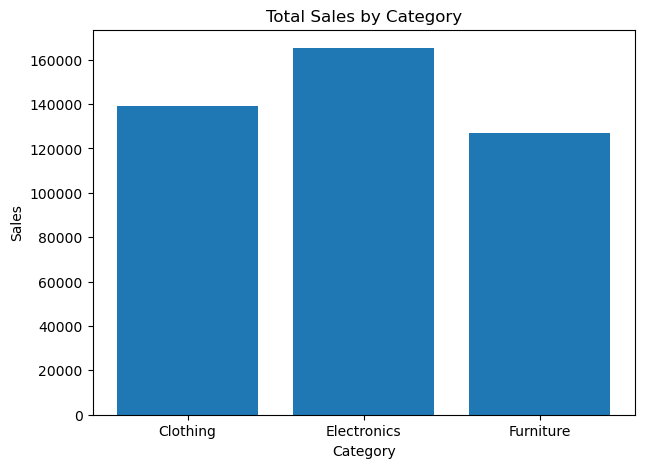

In [60]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.bar(final_summary["Category"], final_summary["Total_Sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

## Profit Margin by category

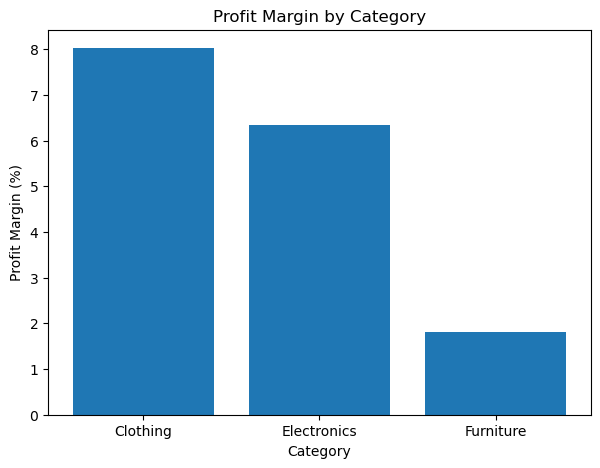

In [19]:
plt.figure(figsize=(7,5))
plt.bar(final_summary["Category"], final_summary["Profit Margin (%)"])
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.show()

### Average profit per order

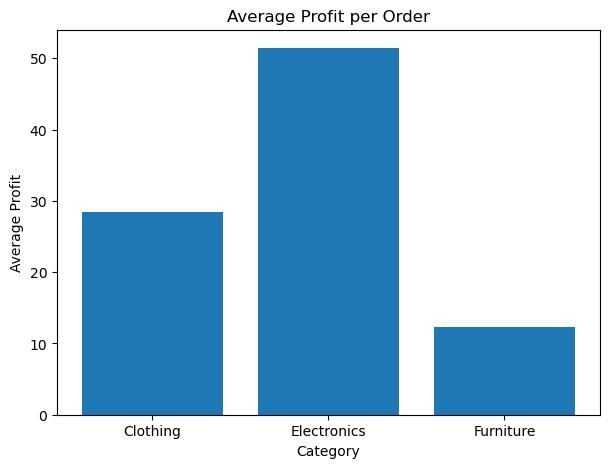

In [20]:
plt.figure(figsize=(7,5))
plt.bar(final_summary["Category"], final_summary["Average Profit per Order"])
plt.title("Average Profit per Order")
plt.xlabel("Category")
plt.ylabel("Average Profit")
plt.show()

### Key Business Insights

- Electronics is the strongest revenue-generating category and delivers the highest average profit per order.
- Clothing has the highest profit margin, indicating efficient pricing and healthy profitability.
- Furniture underperforms across all key metrics, making it the highest-priority category for business improvement.
- Revenue and profitability do not always move together, highlighting the importance of tracking multiple business metrics rather than sales alone.

Furniture

In [23]:
furniture_target = targets[targets["Category"] == "Furniture"].copy()

furniture_target

,Month of Order Date,Category,Target
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900
5,2026-09-18,Furniture,11000
6,2026-10-18,Furniture,11100
7,2026-11-18,Furniture,11300
8,2026-12-18,Furniture,11400
9,2026-01-19,Furniture,11500


### Sorting by Month

In [24]:
furniture_target = furniture_target.sort_values("Month of Order Date")

furniture_target

,Month of Order Date,Category,Target
9,2026-01-19,Furniture,11500
10,2026-02-19,Furniture,11600
11,2026-03-19,Furniture,11800
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900
5,2026-09-18,Furniture,11000
6,2026-10-18,Furniture,11100


### Month-over-Month Percentage Change

In [25]:
furniture_target["MoM Change (%)"] = (
    furniture_target["Target"]
    .pct_change() * 100
)

furniture_target

,Month of Order Date,Category,Target,MoM Change (%)
9,2026-01-19,Furniture,11500,NaN
10,2026-02-19,Furniture,11600,0.869565
11,2026-03-19,Furniture,11800,1.724138
0,2026-04-18,Furniture,10400,-11.864407
1,2026-05-18,Furniture,10500,0.961538
2,2026-06-18,Furniture,10600,0.952381
3,2026-07-18,Furniture,10800,1.886792
4,2026-08-18,Furniture,10900,0.925926
5,2026-09-18,Furniture,11000,0.917431
6,2026-10-18,Furniture,11100,0.909091


### Round values

In [33]:
furniture_target["MoM Change (%)"] = furniture_target["MoM Change (%)"].round(2)

furniture_target

,Month of Order Date,Category,Target,MoM Change (%)
9,2026-01-19,Furniture,11500,NaN
10,2026-02-19,Furniture,11600,0.87
11,2026-03-19,Furniture,11800,1.72
0,2026-04-18,Furniture,10400,-11.86
1,2026-05-18,Furniture,10500,0.96
2,2026-06-18,Furniture,10600,0.95
3,2026-07-18,Furniture,10800,1.89
4,2026-08-18,Furniture,10900,0.93
5,2026-09-18,Furniture,11000,0.92
6,2026-10-18,Furniture,11100,0.91


### Trend Analysis

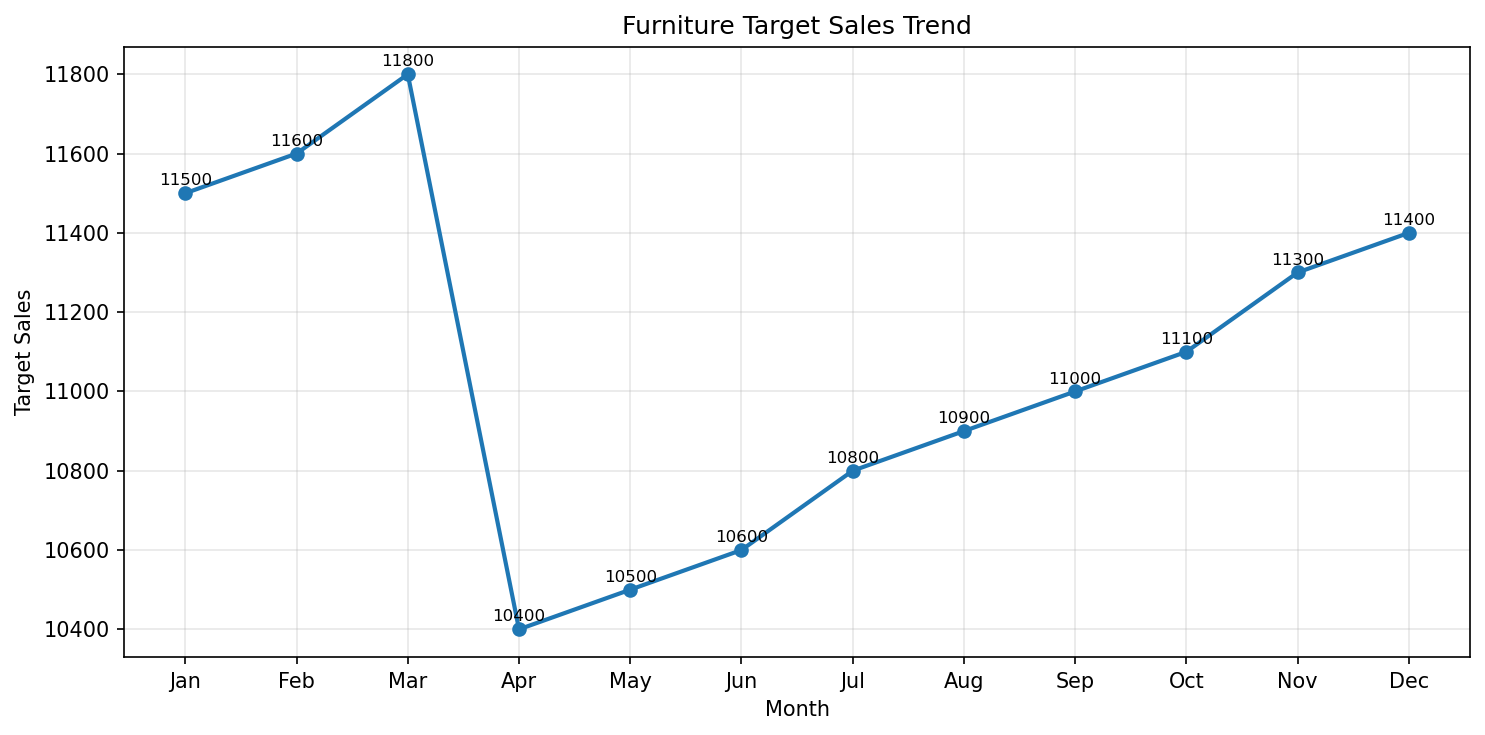

In [44]:
import matplotlib.pyplot as plt

months = furniture_target["Month of Order Date"].dt.strftime("%b")

plt.figure(figsize=(10,5), dpi=150)

plt.plot(months, furniture_target["Target"],
         marker="o", linewidth=2)

for x, y in zip(months, furniture_target["Target"]):
    plt.text(x, y + 20, str(y),
             ha="center", fontsize=8)

plt.title("Furniture Target Sales Trend")
plt.xlabel("Month")
plt.ylabel("Target Sales")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Month-over-Month Change

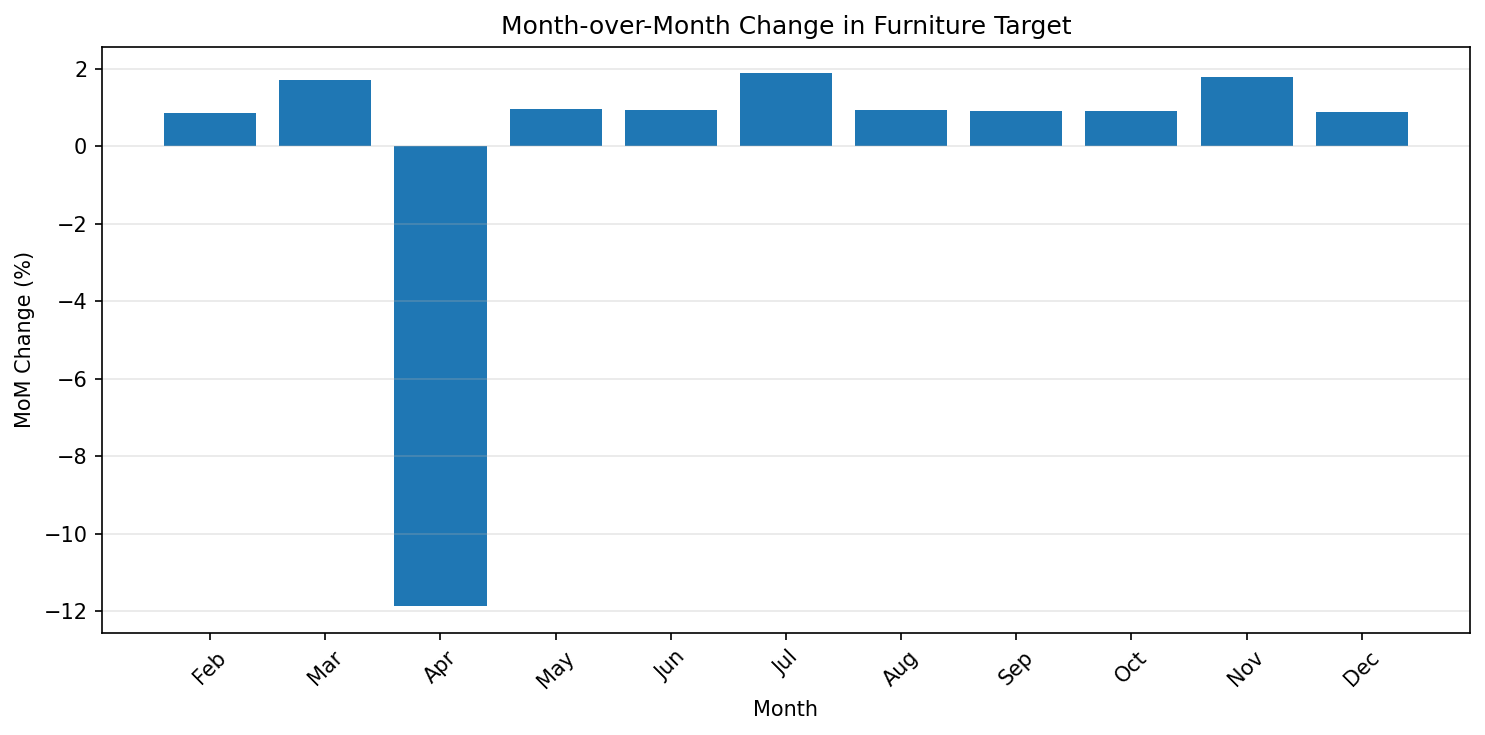

In [49]:
plt.figure(figsize=(10,5), dpi=150)

plt.bar(
    furniture_target["Month of Order Date"].dt.strftime("%b"),
    furniture_target["MoM Change (%)"]
)

plt.title("Month-over-Month Change in Furniture Target")
plt.xlabel("Month")
plt.ylabel("MoM Change (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Analyze Regional Performance

### Calculating Sales

In [50]:
state_sales = (
    merged_df.groupby("State")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_sales

,State,Amount
0,Madhya Pradesh,105140
1,Maharashtra,95348
2,Delhi,22531
3,Uttar Pradesh,22359
4,Rajasthan,21149
5,Gujarat,21058
6,Punjab,16786
7,Karnataka,15058
8,West Bengal,14086
9,Kerala,13459


## Top 5 States by Sales

In [51]:
top5_states = state_sales.head(5)

top5_states

,State,Amount
0,Madhya Pradesh,105140
1,Maharashtra,95348
2,Delhi,22531
3,Uttar Pradesh,22359
4,Rajasthan,21149


## Bottom 5 States by Sales

In [52]:
bottom5_states = state_sales.tail(5)

bottom5_states

,State,Amount
14,Haryana,8863
15,Himachal Pradesh,8666
16,Goa,6705
17,Tamil Nadu,6087
18,Sikkim,5276


### Average Profit by Sales

In [53]:
state_profit = (
    merged_df.groupby("State")["Profit"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

state_profit

,State,Profit
0,Haryana,50.961538
1,Uttar Pradesh,47.602941
2,Kerala,41.577778
3,Delhi,40.364865
4,West Bengal,39.682540
5,Himachal Pradesh,22.620690
6,Maharashtra,21.296552
7,Rajasthan,16.986486
8,Sikkim,16.708333
9,Madhya Pradesh,16.326471


## Visualization

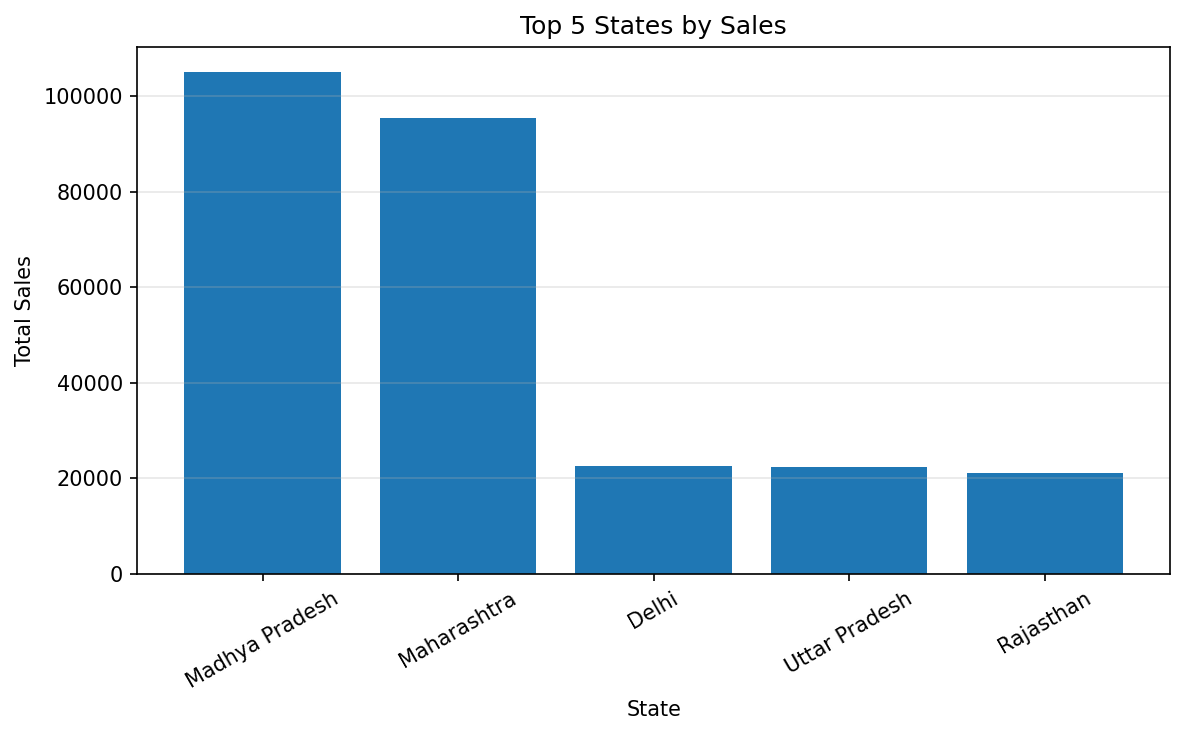

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5), dpi=150)

plt.bar(
    top5_states["State"],
    top5_states["Amount"]
)

plt.title("Top 5 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Regional Performance Insights

- Madhya Pradesh recorded the highest sales (₹105,140), followed by Maharashtra (₹95,348), making them the strongest revenue-generating regions.
- Delhi, Uttar Pradesh, and Rajasthan also ranked among the top five contributors, although their sales were significantly lower than the top two states.
- Sikkim, Tamil Nadu, Goa, Himachal Pradesh, and Haryana generated the lowest sales, indicating lower market penetration or customer demand.
- Haryana recorded the highest average profit per transaction despite relatively low sales, suggesting that its sales are highly profitable.
- Tamil Nadu had the lowest average profit (-₹88.64), indicating that discounts, pricing strategy, or operational costs may be reducing profitability.

### Recommendations

- Continue investing in Madhya Pradesh and Maharashtra through customer retention programs and targeted marketing campaigns to maximize revenue.
- Investigate the reasons behind low sales in Sikkim, Tamil Nadu, and Goa, and run localized marketing campaigns to improve market penetration.
- Analyze why Haryana generates high profits despite lower sales and replicate successful pricing or product strategies in other regions.
- Review pricing, discount policies, and logistics in Tamil Nadu to improve profitability and reduce losses.
- Allocate inventory and marketing budgets based on regional performance to improve overall sales efficiency.

**Key Observation:** Highest Sales ≠ Highest Profit

- **Madhya Pradesh** generated the highest sales but only a moderate average profit (₹16.33).
- **Haryana** generated relatively low sales but achieved the highest average profit (₹50.96).
- This suggests that maximizing revenue alone does not guarantee higher profitability.